In [33]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
np.__version__

'1.20.2'

In [34]:

tf.version.VERSION

'2.8.0'

In [35]:
tf.version.VERSION

'2.8.0'

In [36]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "use_these_images"

In [37]:
# Funktion zum Einlesen der Bilder und Labels
def load_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          # label = filename.split('_')[1].split(".")[0]
          label = filename.split("_")[4].split(".")[0]
        else:
          continue

        label = float(label)

        img = cv2.imread(os.path.join(directory, filename))
        img = cv2.resize(img, IMAGE_SIZE)
        img = img / 255.0

        images.append(img)
        labels.append(label)
  # hier einmal die Spiegelung der bestehenden Bilder
    for i in range(len(images)):
       images.append(images[i][:,::-1,:])
       labels.append(180-labels[i])
      

    return np.array(images), np.array(labels)

In [38]:
def plot_train_history(history):
  plt.plot(history.history['loss'], color='blue')
  plt.plot(history.history['val_loss'], color='red')
  plt.legend(["training loss", "validation loss"])

In [39]:
# Bilder und Labels laden
images, labels = load_images_from_directory(IMAGE_DIRECTORY)

labels

array([ 81., 102., 100., 102.,  92.,  83.,  81.,  83.,  81.,  78.,  51.,
        52.,  55.,  52.,  51.,  61.,  50.,  67.,  46.,  59.,  94.,  63.,
        55.,  71.,  80.,  74.,  73.,  86.,  97., 102., 101.,  41.,  52.,
        90.,  90.,  90.,  72.,  71.,  63.,  71.,  46.,  51.,  50.,  90.,
        50.,  79.,  72.,  62.,  69.,  67., 121.,  72.,  71.,  74.,  72.,
        75.,  73.,  71.,  69.,  87.,  45.,  86.,  77.,  84.,  90., 135.,
       112.,  45.,  45.,  54.,  77.,  98., 118., 135.,  45.,  45.,  45.,
        45.,  45.,  91., 135.,  47.,  45.,  45.,  45.,  45.,  53.,  45.,
        90., 135.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  66.,
       103.,  84.,  87., 124.,  99.,  98.,  90.,  93.,  85.,  94.,  94.,
       100.,  83.,  73.,  85.,  58.,  77.,  87.,  55.,  55.,  53.,  65.,
        74.,  57.,  75.,  56.,  52.,  88.,  95., 115., 107., 100., 104.,
       107., 135., 102., 107., 135., 102., 108.,  99.,  98.,  99., 105.,
       106., 108., 112., 121.,  45.,  64.,  65., 12

24.03.2024 gespiegletes Bild anzeigen abhängig von Bilerzahl sieh Zahl in []

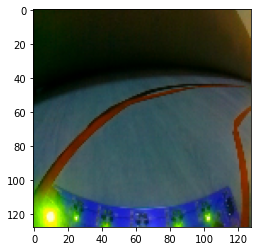

In [40]:
plt.imshow(images[195])

In [41]:
print(images.shape)
print(labels)

(692, 128, 128, 3)
[ 81. 102. 100. 102.  92.  83.  81.  83.  81.  78.  51.  52.  55.  52.
  51.  61.  50.  67.  46.  59.  94.  63.  55.  71.  80.  74.  73.  86.
  97. 102. 101.  41.  52.  90.  90.  90.  72.  71.  63.  71.  46.  51.
  50.  90.  50.  79.  72.  62.  69.  67. 121.  72.  71.  74.  72.  75.
  73.  71.  69.  87.  45.  86.  77.  84.  90. 135. 112.  45.  45.  54.
  77.  98. 118. 135.  45.  45.  45.  45.  45.  91. 135.  47.  45.  45.
  45.  45.  53.  45.  90. 135.  45.  45.  45.  45.  45.  45.  45.  45.
  66. 103.  84.  87. 124.  99.  98.  90.  93.  85.  94.  94. 100.  83.
  73.  85.  58.  77.  87.  55.  55.  53.  65.  74.  57.  75.  56.  52.
  88.  95. 115. 107. 100. 104. 107. 135. 102. 107. 135. 102. 108.  99.
  98.  99. 105. 106. 108. 112. 121.  45.  64.  65. 125. 128. 135.  97.
 101. 102.  98.  99. 100. 100. 110. 106. 106. 109. 111. 111. 103. 105.
 105. 101. 112. 106. 101. 135. 135.  85.  86. 130.  83.  96. 118. 128.
 125. 120. 109.  76. 133. 134. 131. 119. 124. 124. 123.  7

In [42]:
# Durchschnitt der Labelwerte
np.mean(labels)

90.0

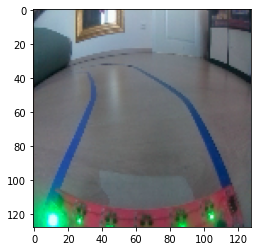

In [43]:
plt.imshow(images[0][:,:,::-1])

In [44]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

Adam wird spezifiziert

In [45]:
from tensorflow.keras.optimizers import Adam


In [46]:
 # Modell für Regression kompilieren
model.compile(optimizer=Adam(learning_rate = 0.001), loss='mean_squared_error', metrics=['mae'])
#model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [47]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 flatten_1 (Flatten)         (None, 100352)           

Checkpoint hier wird das Beste Model aus der 50-reihe von val_loss gespeichert

In [48]:
cp_cb = tf.keras.callbacks.ModelCheckpoint('cp_model.keras', save_best_only=True, monitor='val_loss', mode="min")

hier bricht er das lernen ab wenn der val_loss sich nach drei mal nicht verbessert

In [49]:
es_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

Lernrate automatisch verringern

Lernrate wird geändert bspw. adam = 0.001 bei Faktor 0.1 Lernrte = 0.001*0.1 = 0.0001

In [50]:
rp_cb= tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)

In [51]:
from sklearn.model_selection import train_test_split
images_train, images_test, labels_train, labels_test = train_test_split(images, labels, random_state=42)

In [52]:
#history = model.fit(images_train, labels_train, epochs=50, validation_data= (images_test, labels_test), batch_size=128)

# nötig für die nutzung Abruch mit den Callback-Funktionen
history = model.fit(images_train, labels_train, epochs=100, validation_data= (images_test, labels_test), batch_size=32, callbacks = [cp_cb, es_cb, rp_cb])

Epoch 1/100
3/3 [==============================] - 7s 2s/step - loss: 8534.6084 - mae: 88.0507 - val_loss: 2952.1191 - val_mae: 45.7670 - lr: 0.0010
Epoch 2/100
3/3 [==============================] - 7s 2s/step - loss: 2612.1521 - mae: 42.2534 - val_loss: 1314.9802 - val_mae: 30.7791 - lr: 0.0010
Epoch 3/100
3/3 [==============================] - 6s 2s/step - loss: 1886.8687 - mae: 34.2926 - val_loss: 1952.2939 - val_mae: 35.5259 - lr: 0.0010
Epoch 4/100
3/3 [==============================] - 6s 2s/step - loss: 2142.7468 - mae: 38.0414 - val_loss: 1222.9945 - val_mae: 27.5384 - lr: 0.0010
Epoch 5/100
3/3 [==============================] - 6s 2s/step - loss: 1671.7239 - mae: 32.8418 - val_loss: 1019.7457 - val_mae: 25.8395 - lr: 0.0010
Epoch 6/100
3/3 [==============================] - 6s 2s/step - loss: 1388.1910 - mae: 30.8705 - val_loss: 1026.9229 - val_mae: 25.3432 - lr: 0.0010
Epoch 7/100
3/3 [==============================] - 6s 2s/step - loss: 1371.0333 - mae: 29.8869 - val_loss:

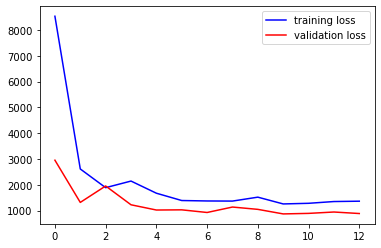

In [53]:
plot_train_history(history)

In [54]:
model.save('my_model.keras') #.keras

In [55]:
loaded_model = tf.keras.models.load_model('my_model.keras')

In [56]:
y_pred = loaded_model.predict(images_test)

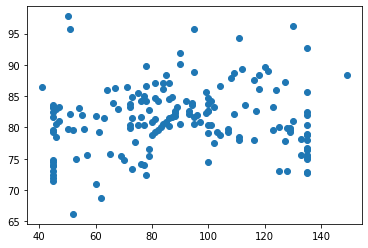

In [57]:
# idealerweise schwanken werte um die Winkelhalbierende
plt.scatter(labels_test, y_pred)

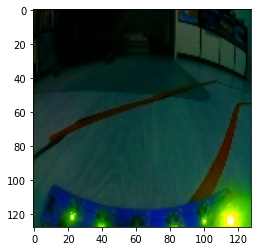

In [58]:
plt.imshow(images_test[170])

In [59]:
np.argmax(labels_test)

170

In [60]:
np.max(labels_test)

149.0

In [61]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

In [62]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\DSI0NTH\AppData\Local\Temp\tmp0tqv67nz\assets


INFO:tensorflow:Assets written to: C:\Users\DSI0NTH\AppData\Local\Temp\tmp0tqv67nz\assets


In [63]:
with open("TFLite_Modell.tflite", 'wb') as f:
    f.write(tflite_model)

In [64]:
np.__version__

'1.20.2'